In [ ]:
%%capture
# Observação: para utilizar o scikeras, precisamos manter a versão do scikit-learn em 1.5.2.
# Versões a partir da 1.6 introduziram alterações que, no momento, não são compatíveis com o scikeras.
!pip install scikit-learn==1.5.2
!pip install scikeras>=1.0.0

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

# Carregar Iris dataset (conjuntos X e d)
![dataset-cover[1].jpg](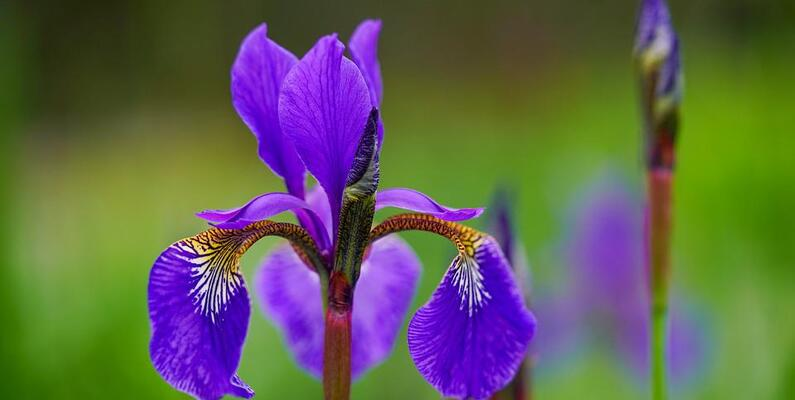)


*   Disponibilizado pelo scikit-learn: https://scikit-learn.org/1.2/auto_examples/datasets/plot_iris_dataset.html
*   Também disponível no Kaggle: https://www.kaggle.com/datasets/himanshunakrani/iris-dataset
*   Também disponível no UCI: https://archive.ics.uci.edu/dataset/53/iris



In [ ]:
iris = load_iris()
X = iris.data                # (150, 4)
d = iris.target              # (150,) com classes 0,1,2
class_names = iris.target_names

print("X:", X.shape, "d:", d.shape, "classes:", np.unique(d))

X: (150, 4) d: (150,) classes: [0 1 2]


In [ ]:
print("X (amostra):\n", X[:5])
print("d (completo):\n", d)

X (amostra):
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
d (completo):
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## Divisão treino/teste e validação + normalização

In [ ]:
# treino+val vs teste
X_trainval, X_test, d_trainval, d_test = train_test_split(
    X, d, test_size=0.20, random_state=42, stratify=d
)

# treino vs validação
X_train, X_val, d_train, d_val = train_test_split(
    X_trainval, d_trainval, test_size=0.16, random_state=42, stratify=d_trainval
)

# normalização (fit só no treino)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# one-hot (para saída softmax + categorical_crossentropy)
d_train_oh = to_categorical(d_train, num_classes=3)
d_val_oh   = to_categorical(d_val,   num_classes=3)
d_test_oh  = to_categorical(d_test,  num_classes=3)

print("Treino:", X_train.shape, d_train_oh.shape)
print("Val:   ", X_val.shape,   d_val_oh.shape)
print("Teste: ", X_test.shape,  d_test_oh.shape)

Treino: (100, 4) (100, 3)
Val:    (20, 4) (20, 3)
Teste:  (30, 4) (30, 3)


In [ ]:
print("X:\n", X_train[:5])
print("d:\n", d_train_oh[:5])

X:
 [[-1.11801229  1.22494019 -1.3248626  -1.44387786]
 [ 0.19589104 -0.74371369  0.78170879  0.55226665]
 [ 1.50979438 -0.08749573  1.23718368  1.21764815]
 [ 0.55422832 -1.18119233  0.72477443  0.95149555]
 [-0.04300047 -0.96245301  0.15543081  0.01996145]]
d:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


# Modelo:

In [ ]:
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation="tanh"),     # você pode variar 3, 10, 50 depois
    layers.Dense(3, activation="softmax")
])
    # Opções de funções de ativação
      # activation='relu'  # Função mais comum, usada em camadas ocultas
      # activation='sigmoid'  # Para saída binária (0 ou 1)
      # activation='softmax'  # Para classificação multiclasse
      # activation='tanh'  # Alternativa ao ReLU, pode ser útil para dados normalizados
      # activation='linear'  # Retorna a entrada sem modificar, útil em regressões

model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",         # cross-entropy multiclasse (one-hot)
    metrics=["accuracy"]
)
  ## Alternativas dos parâmetros acima:
  #1 Opções de otimizadores
      # optimizer='sgd'  # Stochastic Gradient Descent (descida do gradiente estocástica)
      # optimizer='adagrad'  # Adaptive Gradient, ajusta taxa de aprendizado automaticamente
      # optimizer='adam'  # Adaptive Moment Estimation (Adam)
      # optimizer='nadam'  # Nesterov-accelerated Adaptive Moment Estimation, variação do Adam
  #2 Opções de funções de perda (loss)
      # loss='categorical_crossentropy'  # Para classificação multiclasse com one-hot encoding
      # loss='sparse_categorical_crossentropy'  # Para classificação multiclasse com labels inteiros
      # loss='binary_crossentropy'  # Para classificação binária (0 ou 1)
      # loss='mean_squared_error'  # Erro quadrático médio, usado em regressão
      # loss='mean_absolute_error'  # Erro absoluto médio, penaliza menos que MSE
      # loss='huber'  # Combinação de MSE e MAE, útil para lidar com outliers
  #3 Opções de métricas de avaliação (colocar quantas quiser)
      # metrics=['accuracy']  # Para classificação com classes balanceadas
      # metrics=['precision', 'recall']  # Para problemas desbalanceados
      # metrics=['mse']  # Mean Squared Error, usado para regressão
      # metrics=['mae']  # Mean Absolute Error, usado para regressão

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Como foram calculados os valores da coluna Param?
<center>
<img src="https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEgZ1onrToMXESCQG6HBk-eOF9Hp1LYt_-dz8H4TcP_e4XkgECQyosZ7Y1NUAibzwGYvCllH2IfMrBHXE9RbH4C_KnhkOa3E382hst8LzqyfwUMTSdolM8GZha_w4shhNbRZIUFeS9H9c4Blwke5bKs5Jfn8-3gd_BhzsSptBBoYbD3YaJJCbYCV--xIvA/w584-h329/Neural%20network%20weights%20and%20bias%20(1).png" width="400">
</center>

# Treino:

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
# Opções de monitoramento para EarlyStopping
    # monitor='val_loss'  # Perda no conjunto de validação (mais comum)
    # monitor='loss'  # Perda no conjunto de treino
    # monitor='val_accuracy'  # Acurácia no conjunto de validação
    # monitor='accuracy'  # Acurácia no conjunto de treino
history = model.fit(
    X_train, d_train_oh,
    validation_data=(X_val, d_val_oh),
    epochs=100,
    batch_size=2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6500 - loss: 0.8145 - val_accuracy: 0.8500 - val_loss: 0.6081
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8000 - loss: 0.5542 - val_accuracy: 0.7500 - val_loss: 0.4967
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.4738 - val_accuracy: 0.7500 - val_loss: 0.4490
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8200 - loss: 0.4302 - val_accuracy: 0.7500 - val_loss: 0.4186
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8500 - loss: 0.3997 - val_accuracy: 0.8000 - val_loss: 0.3957
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8500 - loss: 0.3756 - val_accuracy: 0.8000 - val_loss: 0.3770
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8700 - loss: 0.3553 - val_accuracy: 0.8500 - val_loss: 0.3610
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.3377 - val_accuracy: 0.9000 - v

## Avaliação (no conjunto de teste)

In [ ]:
test_loss, test_acc = model.evaluate(X_test, d_test_oh, verbose=0)
print("Loss teste:", test_loss)
print("Accuracy teste:", test_acc)

Loss teste: 0.1010742038488388
Accuracy teste: 0.9666666388511658


### Plotagem das curvas de loss e acuraccy

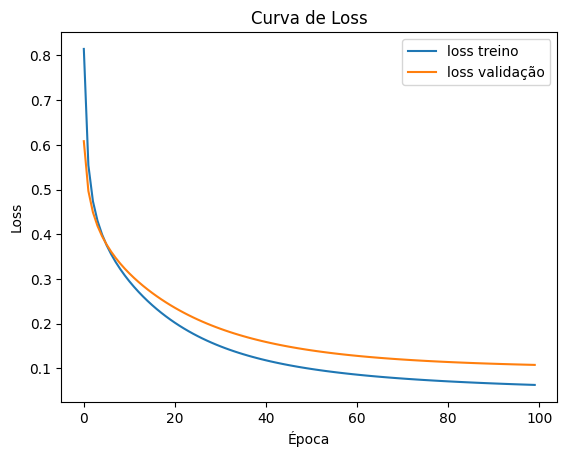

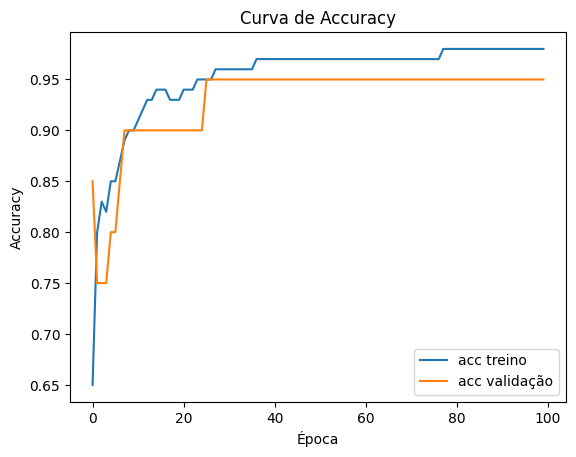

In [ ]:
plt.plot(history.history["loss"], label="loss treino")
plt.plot(history.history["val_loss"], label="loss validação")
plt.legend()
plt.title("Curva de Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="acc treino")
plt.plot(history.history["val_accuracy"], label="acc validação")
plt.legend()
plt.title("Curva de Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.show()

### Matriz de confusão:

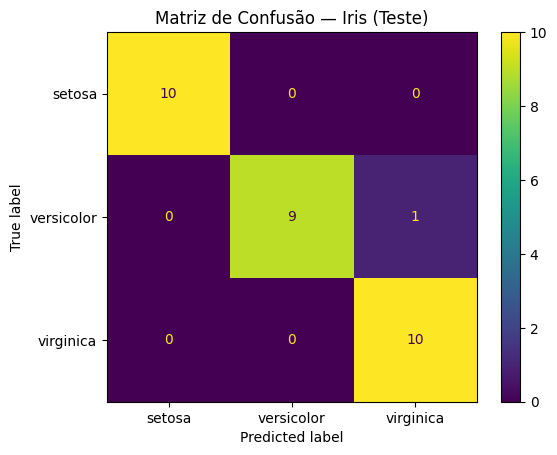

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
probs = model.predict(X_test, verbose=0)
y = np.argmax(probs, axis=1)

cm = confusion_matrix(d_test, y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Matriz de Confusão — Iris (Teste)")
plt.show()

print(classification_report(d_test, y, target_names=class_names))

#### Algumas respostas/classificações da rede:

In [ ]:
for i in range(min(10, len(X_test))):
    print(
        f"Real: {class_names[d_test[i]]:10s} | Prev: {class_names[y[i]]:10s} | probs={np.round(probs[i], 3)}"
    )

Real: setosa     | Prev: setosa     | probs=[0.996 0.004 0.   ]
Real: virginica  | Prev: virginica  | probs=[0.    0.147 0.853]
Real: versicolor | Prev: versicolor | probs=[0.042 0.957 0.001]
Real: versicolor | Prev: versicolor | probs=[0.022 0.976 0.001]
Real: setosa     | Prev: setosa     | probs=[0.997 0.003 0.   ]
Real: versicolor | Prev: versicolor | probs=[0.005 0.754 0.24 ]
Real: setosa     | Prev: setosa     | probs=[0.998 0.002 0.   ]
Real: setosa     | Prev: setosa     | probs=[0.99 0.01 0.  ]
Real: virginica  | Prev: virginica  | probs=[0.    0.023 0.977]
Real: versicolor | Prev: versicolor | probs=[0.009 0.82  0.17 ]


# Ajuste de hiperparâmetros

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

### Função para criar a rede com hiperparâmetros variáveis

In [ ]:
def criar_rede_finetuning(optimizer="sgd",
                          kernel_initializer="glorot_uniform",
                          activation="tanh",
                          neurons=8):

    tf.keras.backend.clear_session()

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        tf.keras.layers.Dense(
            units=neurons,
            activation=activation,
            kernel_initializer=kernel_initializer
        ),
        tf.keras.layers.Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Encapsular o modelo no KerasClassifier

In [ ]:
classificador = KerasClassifier(
    model=criar_rede_finetuning
)

## Definir a grade de hiperparâmetros

In [ ]:
parametros = {
    "batch_size": [4, 8],
    "epochs": [10],
    "model__optimizer": ["sgd","nadam"],
    "model__kernel_initializer": ["random_uniform"],
    "model__activation": ["tanh"],
    "model__neurons": [8, 16, 32]
}

## Executar o Grid Search

In [ ]:
grid_search = GridSearchCV(
    estimator=classificador,
    param_grid=parametros,
    cv=3,
    scoring="accuracy"
)

grid_search.fit(X_train, d_train_oh)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6515 - loss: 1.0367  
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7879 - loss: 0.9523 
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7879 - loss: 0.8816  
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8485 - loss: 0.8213 
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8636 - loss: 0.7696 
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8636 - loss: 0.7247 
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8636 - loss: 0.6857 
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8636 - loss: 0.6515 
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8636 - loss: 0.6214 
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.5947 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7164 - loss: 1.0460
Epoch 2/10
17/17 ━━━━━━━━

GridSearchCV(cv=3,
             estimator=KerasClassifier(model=<function criar_rede_finetuning at 0x7fe67ec4c7c0>),
             param_grid={'batch_size': [4, 8], 'epochs': [10],
                         'model__activation': ['tanh'],
                         'model__kernel_initializer': ['random_uniform'],
                         'model__neurons': [8, 16, 32],
                         'model__optimizer': ['sgd', 'nadam']},
             scoring='accuracy')

### Resultados rankeados

In [ ]:
import pandas as pd

resultados = pd.DataFrame(grid_search.cv_results_)

tabela_resultados = resultados[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_batch_size',
    'param_epochs',
    'param_model__optimizer',
    'param_model__kernel_initializer',
    'param_model__activation',
    'param_model__neurons'
]].copy()

tabela_resultados.columns = [
    'ranking',
    'acuracia',
    'd_padrao',
    'batch',
    'epochs',
    'optimizer',
    'kernel_initializer',
    'activation',
    'neurons'
]

tabela_resultados = tabela_resultados.sort_values(by='ranking')

print(tabela_resultados)

# Melhor Resultado
melhores_parametros = grid_search.best_params_
melhor_precisao = grid_search.best_score_

print("Melhores parâmetros encontrados:", melhores_parametros)
print("Melhor precisão obtida:", melhor_precisao)

    ranking  acuracia  d_padrao  batch  epochs optimizer kernel_initializer  \
5         1  0.859180  0.057980      4      10     nadam     random_uniform   
4         2  0.849673  0.026211      4      10       sgd     random_uniform   
3         3  0.838978  0.076384      4      10     nadam     random_uniform   
11        4  0.818776  0.090017      8      10     nadam     random_uniform   
2         5  0.799762  0.029910      4      10       sgd     random_uniform   
0         6  0.799465  0.039785      4      10       sgd     random_uniform   
10        7  0.779560  0.031091      8      10       sgd     random_uniform   
7         8  0.768271  0.137019      8      10     nadam     random_uniform   
9         9  0.759655  0.027329      8      10     nadam     random_uniform   
6        10  0.750446  0.033852      8      10       sgd     random_uniform   
8        11  0.730838  0.060519      8      10       sgd     random_uniform   
1        12  0.719548  0.080804      4      10     n